C:\Users\Dede\AppData\Local\Temp\ipykernel_11564\3144976750.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Tanggal'] = pd.to_datetime(df['Tanggal'])


Bentuk X_train: (2001, 60, 1)
Bentuk X_test: (446, 60, 1)

Memulai proses training LSTM...
Epoch 1/50


c:\Users\Dede\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0130 - val_loss: 0.0011
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0031 - val_loss: 0.0016
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0026 - val_loss: 0.0048
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0022 - val_loss: 0.0027
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0022 - val_loss: 0.0067
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 0.0020 - val_loss: 0.0038
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0015 - val_loss: 0.0043
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0013 - val_loss: 0.0040
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0012 - val_l


>>> Model LSTM berhasil disimpan di: '../model\lstm_model.h5' <<<
>>> Scaler LSTM berhasil disimpan di: '../model\lstm_scaler.pkl' <<<

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step

      HASIL EVALUASI MODEL LSTM
Mean Absolute Error (MAE)     : Rp 57.06
Root Mean Squared Error (RMSE): Rp 74.77
Mean Absolute Perc. Error (MAPE): 0.36%



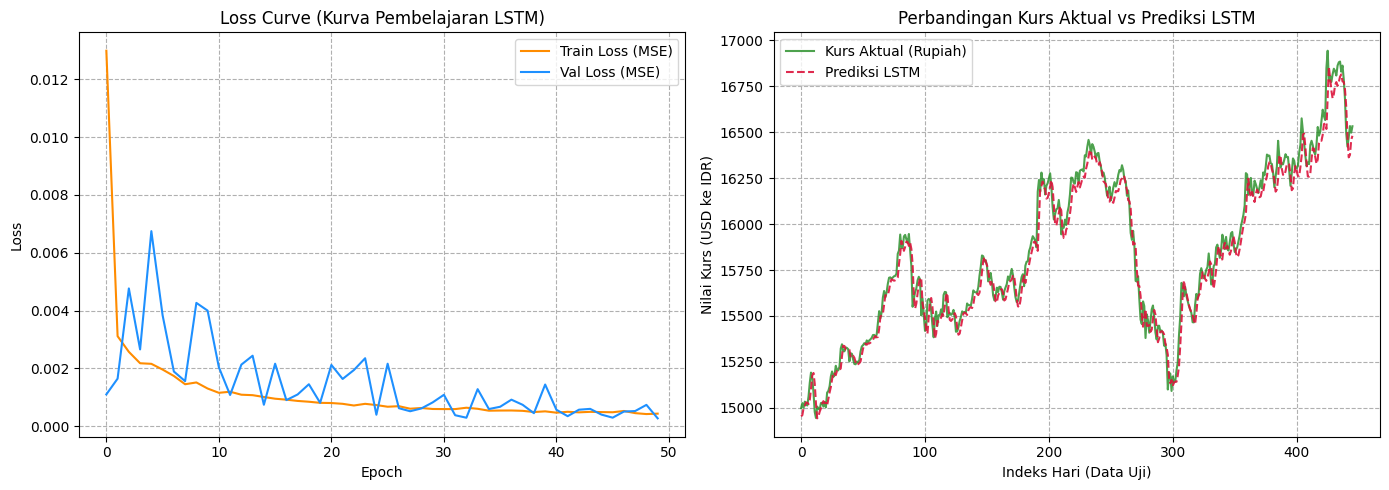

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os  # Tambahan untuk membuat folder otomatis
import joblib  # Tambahan untuk menyimpan objek scaler (.pkl/.joblib)
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =====================================================================
# 1. LOAD DAN PREPROCESSING DATA
# =====================================================================
# Baca dataset
df = pd.read_csv('../data/USD-IDR.csv', sep=';')

# Hilangkan kolom kosong jika ada karena delimiter di akhir baris
df = df.dropna(axis=1, how='all')
df = df.dropna()

# Ubah format Tanggal dan urutkan dari Terdahulu ke Terbaru (Ascending)
# Ini SANGAT PENTING untuk model Time Series seperti LSTM
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal').reset_index(drop=True)

# Ambil nilai Kurs saja
data_kurs = df['Kurs'].values.reshape(-1, 1)

# Normalisasi Data (Scaling ke rentang 0 dan 1) - Sangat disarankan untuk LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_kurs)

# =====================================================================
# 2. PEMBUATAN DATASET (SLIDING WINDOW) UNTUK LSTM
# =====================================================================
# Tentukan berapa hari ke belakang (time_steps) untuk memprediksi hari esok
time_steps = 60 

X = []
Y = []

for i in range(time_steps, len(scaled_data)):
    X.append(scaled_data[i-time_steps:i, 0])
    Y.append(scaled_data[i, 0])

X, Y = np.array(X), np.array(Y)

# Reshape X menjadi 3D [samples, time_steps, features] sesuai syarat input Keras LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split Data: Training (2001 data awal sesuai file Anda sebelumnya) dan Testing (sisanya)
train_size = 2001
if train_size > len(X):
    train_size = int(len(X) * 0.8) # Fallback 80% jika data tidak cukup

X_train, y_train = X[:train_size], Y[:train_size]
X_test, y_test = X[train_size:], Y[train_size:]

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")

# =====================================================================
# 3. MEMBANGUN DAN MELATIH MODEL LSTM
# =====================================================================
model = Sequential()

# Layer LSTM ke-1
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2)) # Mencegah overfitting

# Layer LSTM ke-2
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(units=25, activation='relu'))
model.add(Dense(units=1))

# Compile Model
model.compile(optimizer='adam', loss='mean_squared_error')

# Latih Model
print("\nMemulai proses training LSTM...")
history = model.fit(X_train, y_train, batch_size=32, epochs=50, validation_data=(X_test, y_test), verbose=1)

# =====================================================================
# TAMBAHAN: MENYIMPAN MODEL DAN SCALER KE FOLDER model/
# =====================================================================
# Membuat folder 'model' jika belum ada di direktori kerja saat ini
output_dir = '../model'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 1. Menyimpan Arsitektur & Bobot Model LSTM ke format .h5
model_path = os.path.join(output_dir, 'lstm_model.h5')
model.save(model_path)

# 2. Menyimpan Objek Scaler menggunakan joblib (.pkl atau .joblib)
scaler_path = os.path.join(output_dir, 'lstm_scaler.pkl')
joblib.dump(scaler, scaler_path)

print(f"\n>>> Model LSTM berhasil disimpan di: '{model_path}' <<<")
print(f">>> Scaler LSTM berhasil disimpan di: '{scaler_path}' <<<\n")

# =====================================================================
# 4. PREDIKSI DAN EVALUASI
# =====================================================================
# Prediksi data testing
prediksi_scaled = model.predict(X_test)

# Kembalikan nilai prediksi dan nilai aktual ke skala Rupiah aslinya (Inverse Transform)
prediksi_aktual = scaler.inverse_transform(prediksi_scaled)
y_test_aktual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Menghitung Metrik Evaluasi
mae = mean_absolute_error(y_test_aktual, prediksi_aktual)
rmse = np.sqrt(mean_squared_error(y_test_aktual, prediksi_aktual))

# Menghitung MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test_aktual - prediksi_aktual) / np.where(y_test_aktual==0, 1, y_test_aktual))) * 100

print("\n=============================================")
print("      HASIL EVALUASI MODEL LSTM")
print("=============================================")
print(f"Mean Absolute Error (MAE)     : Rp {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): Rp {rmse:.2f}")
print(f"Mean Absolute Perc. Error (MAPE): {mape:.2f}%")
print("=============================================\n")

# =====================================================================
# 5. VISUALISASI HASIL PREDIKSI VS AKTUAL
# =====================================================================
plt.figure(figsize=(14, 5))

# Plot History Loss (Training vs Validation)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)', color='darkorange')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)', color='dodgerblue')
plt.title('Loss Curve (Kurva Pembelajaran LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--')

# Plot Prediksi vs Aktual
plt.subplot(1, 2, 2)
plt.plot(y_test_aktual, label='Kurs Aktual (Rupiah)', color='forestgreen', alpha=0.8)
plt.plot(prediksi_aktual, label='Prediksi LSTM', color='crimson', linestyle='--', alpha=0.9)
plt.title('Perbandingan Kurs Aktual vs Prediksi LSTM')
plt.xlabel('Indeks Hari (Data Uji)')
plt.ylabel('Nilai Kurs (USD ke IDR)')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()